In [1]:
path = '/content/drive/MyDrive/컴퓨터비전_응용/data/puppy.jpg'

In [2]:
!pip install opencv-python

In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

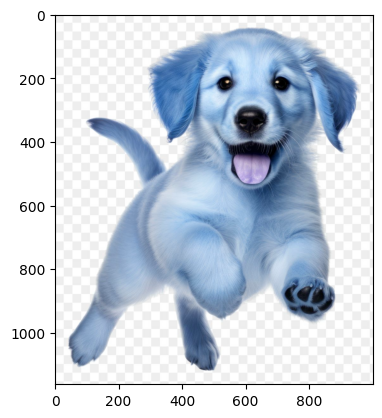

In [7]:
image = cv2.imread(path)

plt.imshow(image)
plt.show()

# 원본 이미지
# 이미지가 파랗게 나온다 >> BGR 이기 때문

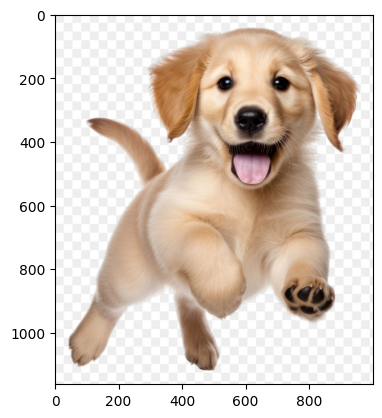

In [9]:
src = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(src)
plt.show()

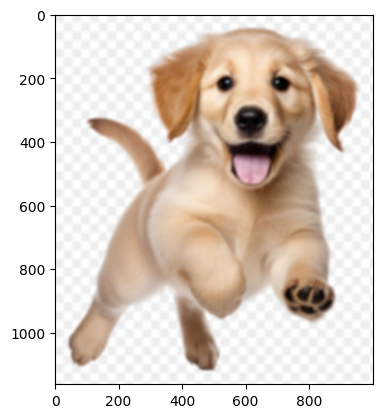

In [12]:
src = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

dst = cv2.blur(src, (11,11))
# blur(적용할 이미지, 커널크기) (default) 평균블러 적용
# 평균블러 : 모든 픽셀에 동일한 가중치 부여

plt.imshow(dst)
plt.show()

커널크기에 따라 blur 효과가 달라짐
- 3*3 커널 : 약간 흐림
- 5*5 커널: 중간적 흐림
- 11*11 커널 : 많이 흐림


왜 이런 일이?
- 작은 커널(3*3) : 주변에 9개 픽셀의 평균
  - 가까운 픽셀만 영향을 받음


- 큰 커널(11*11) : 주변에 121개 픽셀의 평균
  - 멀리 있는 픽셀도 영향을 받음

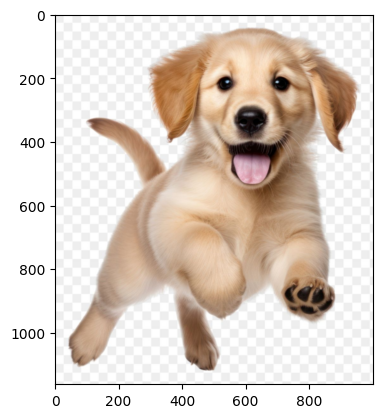

In [13]:
dst = cv2.blur(src, (3,3))

plt.imshow(dst)
plt.show()

커널 크기 규칙
- 홀수만 사용
- 실제 사용 (3,3), (5,5), (7,7),(11,11)
- 왜 홀수인가요?
  - 중앙(값)이 명확(명확한 중심점이 존재)

가우시안 블러(GaussianBlur())
> 중요한 가운데 값이 더 선명. 평균 점수에 더 큰 가중치 부여


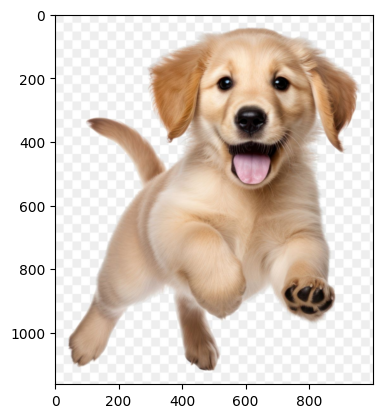

In [15]:
dst = cv2.GaussianBlur(src, ksize=(3,3), sigmaX=0)
# ksize(kernel size) = (3,3)
# sigmaX=0 >> 0 default(opencv 자동계산) (표준편차)

plt.imshow(dst)
plt.show()

# 가우시안 블러 특징
# >> 중앙 픽셀에 더 큰 가중치 부여 (가장 많이 사용)

medianBlur() 중위수(중앙값) 블러

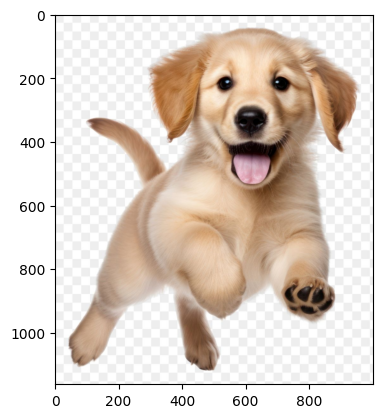

In [17]:
# medianBlur() : 평균의 가장 큰 단점인 '이상치(outlier)'에 강함
# >> 이미지에서 이상치란? Noise

dst = cv2.medianBlur(src, ksize=3)
plt.imshow(dst)
plt.show()

침식(errosion), 팽창(dilate), 열기(opening), 닫기(closing)

In [18]:
path = '/content/drive/MyDrive/컴퓨터비전_응용/data/salt.jpg'

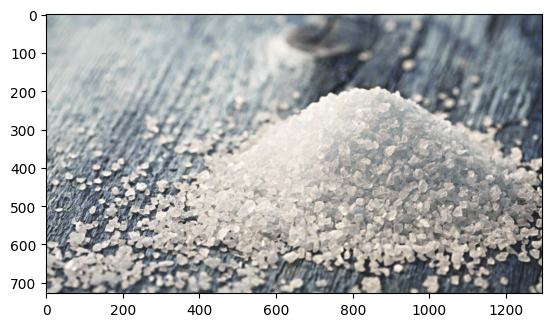

In [21]:
src = cv2.imread(path)

plt.imshow(src)
plt.show()

200.0


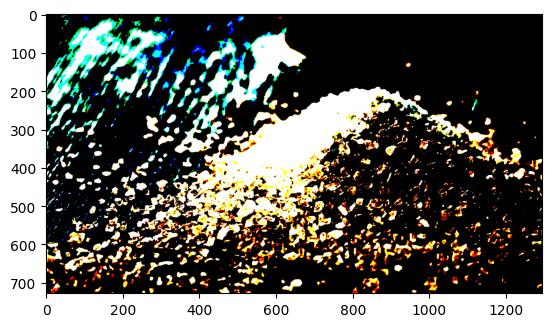

In [25]:
# 이진화(binary) 0, 1 >> 흑백 / 임계치(threshold, 기준값) 넘으면 255(흰색), 모자르면 0(검은색)
# cv2.threshold(적용할 이미지, 임계값(기준값))
# >> 기준을 넘으면 >> 255(흰색)으로 만들어

result, binary_image = cv2.threshold(src, 200, 255, cv2.THRESH_BINARY)
# 200 : 임계값(기준값) >> 넘으면 255(흰색) 만들어라

print(result)   # 임계값
plt.imshow(binary_image)
plt.show()

140.0


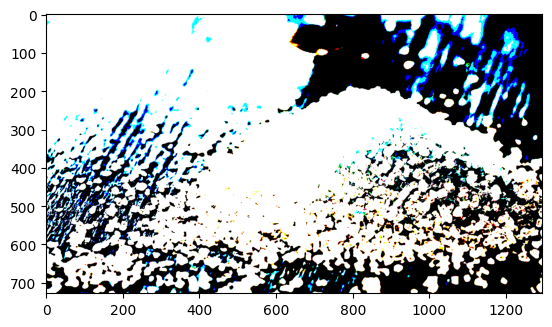

In [27]:
result, binary_image = cv2.threshold(src, 140, 255, cv2.THRESH_BINARY)
# 140 : 임계값(기준값) >> 넘으면 255(흰색) 만들어라

print(result)   # 임계값
plt.imshow(binary_image)
plt.show()

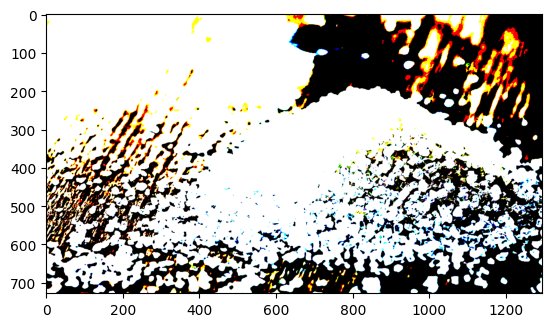

In [29]:
plt.imshow(cv2.cvtColor(binary_image, cv2.COLOR_BGR2RGB))
plt.show()

149.0


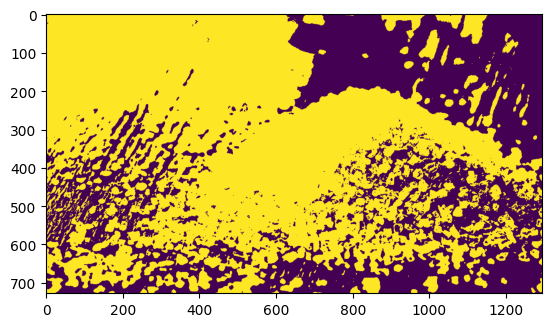

In [33]:
# otsu 알고리즘 사용
# 임계값 직접 설정하기 힘들어. 컴퓨터 너가 해
# 이미지가 grayscale 흑백 사진이어야 함

src_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 임계값 0 설정하고, THRESHOLD_OTSU 더함
result, binary_image_otsu = cv2.threshold(src_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(result)
# 149.0 >> 여기서 나온 result 값이 컴퓨터가 찾아준 최적의 threshold
# cv2.THRESH_OTSU 로 최적의 임계값 찾고, 이것을 기준으로 cv2.THRESH_BINARY가 0이냐 255냐 판단함

plt.imshow(binary_image_otsu)
plt.show()

커널 만들기

In [35]:
# np.empty(사이즈)
# >> 사이즈(size) 크기 만큼 비어 있는 객체 생성
# np.zeros(사이즈)
# >> 사이즈 크기 만큼 0으로 채워져 있는 객체 생성

kernel = np.ones((3,3), np.uint8)
kernel

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

In [38]:
kernel_0 = np.zeros((3,3), np.uint8)
kernel_0

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=uint8)

팽창과 침식 작용
- erosion 침식
  - 흰색 영역(255)의 외곽을 깍아내는 연산
  - 커널이 완전히 흰색을 포함하는 영역만 유지, 나머지는 검정(0)으로 바꿔요
  - 객체가 작아져요(외곽이 깍였으니깐), 작은 노이즈 제거(작은 점 형태 흰색 잡음 제거)


- dialtion 확대(팽창)
  - 흰색 영역(255) 넓혀줘요
  - 커널이 1개 라도 흰색 만나면 중심 픽셀을 흰색으로 확장
  - 객체가 커져요(빈 공간 채워줘요), 끊긴 선 연결(문자, 윤곽선 연결), 구멍 채워줘요


실무 TIP)

1. Binary(0-255)
2. erosion(줄어들고 잡음 제거) 또는 dailtion(커짐, 끊김 영역 연결)

- 일반적으로 외부 노이즈가 문제면, opening 사용
- 내부 구멍이 문제면 closing 사용
- 둘 다 문제면 opening 사용 후, closing

이미지에서 하얀색 객체 기준으로, 튀어나왔거나 끊기는 부분을 노이즈로 구분

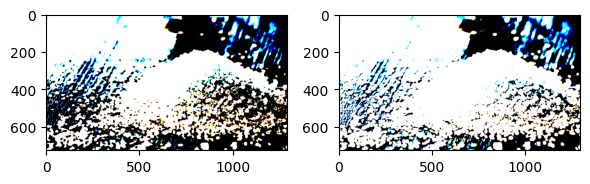

In [41]:
erode_image = cv2.erode(binary_image, kernel, iterations=1)   # 침식된 이미지(외곽 깍임)
# iterations 반복 횟수
dilate_image = cv2.dilate(binary_image, kernel, iterations=1)   # 팽창된 이미지

fig, axes = plt.subplots(1,2, figsize=(6,3))

axes[0].imshow(erode_image)
axes[1].imshow(dilate_image)

plt.tight_layout()
plt.show()

- opening = erosion >> dilation (점 noise 빼고, 구멍 채워)
  - noise 제거한 후, 모형 유지
- closing = dilation >> erosion
  - 끊긴 윤곽선 연결, 구멍 채움

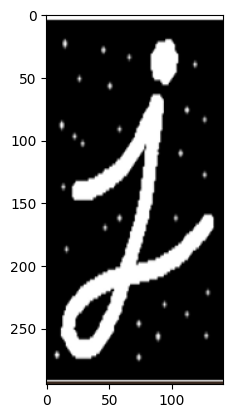

In [42]:
path = '/content/drive/MyDrive/컴퓨터비전_응용/data/noisy_opening.png'

src_opening = cv2.imread(path)

plt.imshow(src_opening)
plt.show()

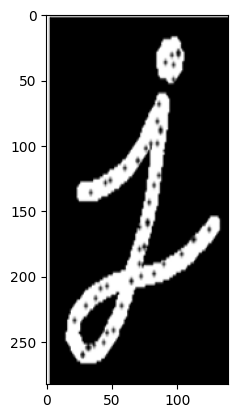

In [45]:
path_closing = '/content/drive/MyDrive/컴퓨터비전_응용/data/noisy_closing.png'

src_closing = cv2.imread(path_closing)

plt.imshow(src_closing)
plt.show()

In [50]:
# 이진화 (binary) 0 또는 1 (흑백)
# 임계값(기준) 넘으면 255(흰색), 모자라면 0(검은색)
# cv2.threshold(적용할 이미지, 임계값(기준))
# >> 기준 넘기면 >> 255(흰색) 만들어줘

result_open, binary_image_open = cv2.threshold(src_opening, 120, 255, cv2.THRESH_BINARY)
result_close, binary_image_close = cv2.threshold(src_closing, 120, 255, cv2.THRESH_BINARY)

print(result_open)   # 120.0 (임계값, 기준)
print(result_close)

120.0
120.0


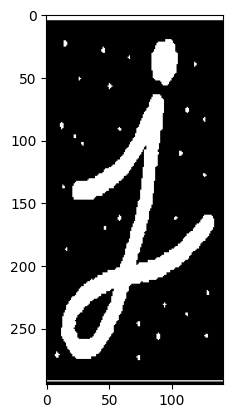

In [47]:
plt.imshow(binary_image_open)
plt.show()

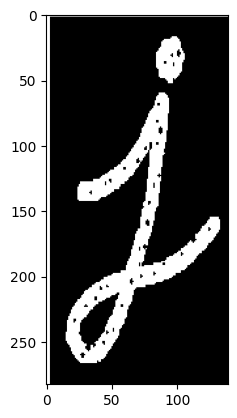

In [49]:
plt.imshow(binary_image_close)
plt.show()

In [ ]:
# close와 open이 큰 효과를 못 거둠.

In [52]:
# 커널 만들기
kernel = np.ones((3,3), np.uint8)
kernel

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

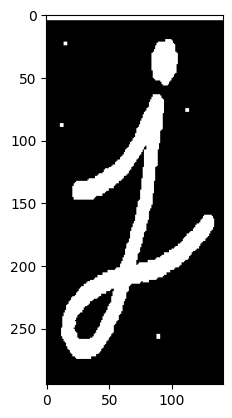

In [53]:
# 열기 (opening)

opening = cv2.morphologyEx(binary_image_open, cv2.MORPH_OPEN, kernel, iterations=1)
# opening 침식 후 팽창(점 빼고 채워넣기)

plt.imshow(opening)
plt.show()

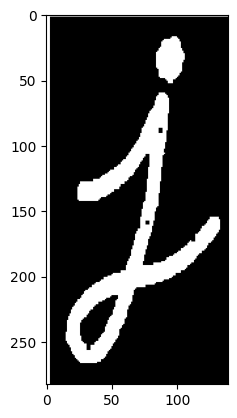

In [55]:
# 닫기 (closing)

closing = cv2.morphologyEx(binary_image_close, cv2.MORPH_CLOSE, kernel, iterations=1)
# closing: 팽창 후 침식

plt.imshow(closing)
plt.show()

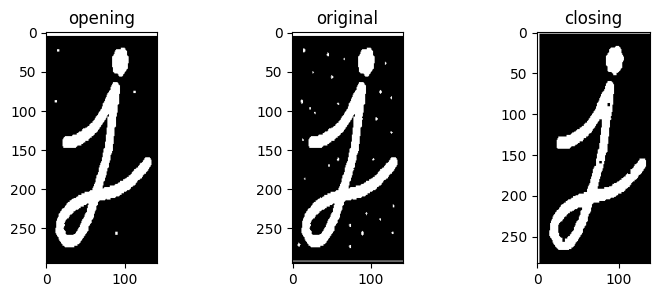

In [57]:
fig, axes = plt.subplots(1,3, figsize=(9,3))

axes[0].imshow(opening)
axes[0].set_title('opening')
axes[1].imshow(binary_image_open)
axes[1].set_title('original')
axes[2].imshow(closing)
axes[2].set_title('closing')

plt.show()